[![ebac_logo-data_science.png](https://raw.githubusercontent.com/FelipeBebas/Resources/refs/heads/main/assets/ebac-banner-reader.png)](https://github.com/FelipeBebas/Curso-EBAC_Profissao_Cientista_de_Dados)

### **Módulo 34** | Regressão III | Exercício 1

**Aluno:** [Felipe Barros de Francisco](https://www.linkedin.com/in/felipe-barros-de-francisco-124a3a9b/)<br>
**Data:** Fevereiro de 2026.

# Regressão III - Tarefa

In [1]:
import numpy                   as np
import pandas                  as pd
import matplotlib.pyplot       as plt
import seaborn                 as sns

import statsmodels.api         as sm
import statsmodels.formula.api as smf

from scipy.interpolate         import interp1d

from sklearn.metrics           import r2_score

In [3]:
# Lendo o arquivo CSV e armazenando os dados em um DataFrame
df = pd.read_csv(filepath_or_buffer='/content/sample_data/previsao_de_renda_II.csv', index_col=0)

# Exibindo informações sobre o DataFrame
df.info()

# Exibindo o DataFrame completo
df

<class 'pandas.core.frame.DataFrame'>
Index: 195962 entries, 2015-01-01 to 2015-04-01
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  195962 non-null  int64  
 1   sexo                   195962 non-null  object 
 2   posse_de_veiculo       195962 non-null  object 
 3   posse_de_imovel        195962 non-null  object 
 4   qtd_filhos             195962 non-null  int64  
 5   tipo_renda             195962 non-null  object 
 6   educacao               195962 non-null  object 
 7   estado_civil           195961 non-null  object 
 8   tipo_residencia        195961 non-null  object 
 9   idade                  195961 non-null  float64
 10  tempo_emprego          163280 non-null  float64
 11  qt_pessoas_residencia  195961 non-null  float64
 12  renda                  195961 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 20.9+ MB


,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
data_ref,,,,,,,,,,,,,
2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47.0,16.717808,2.0,11138.14
2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30.0,9.600000,2.0,2424.81
2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28.0,8.208219,2.0,13749.66
2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44.0,1.301370,4.0,2361.84
2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33.0,1.254795,4.0,790.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-04-01,2924,F,N,S,2,Empresário,Médio,União,Casa,36.0,1.602740,4.0,1116.04
2015-04-01,16260,F,N,S,0,Pensionista,Médio,Solteiro,Casa,61.0,NaN,1.0,4596.60
2015-04-01,9873,F,N,S,0,Assalariado,Superior completo,Casado,Casa,62.0,5.515068,2.0,4858.28


## Avalie valores missing e substitua pela média

Neste exercício não vamos nos preocupar com valores *missing*. Substitua-os pela média.

In [4]:
# Imprimindo a quantidade de valores ausentes para cada variável no DataFrame
print(f'Quantidade de valores missing por variável:\n\n{df.isna().sum()}')

Quantidade de valores missing por variável:

index                        0
sexo                         0
posse_de_veiculo             0
posse_de_imovel              0
qtd_filhos                   0
tipo_renda                   0
educacao                     0
estado_civil                 1
tipo_residencia              1
idade                        1
tempo_emprego            32682
qt_pessoas_residencia        1
renda                        1
dtype: int64


In [5]:
# Criando uma nova variável 'tempo_emprego_fillna_mean' com valores ausentes preenchidos pela média da variável original 'tempo_emprego'
df['tempo_emprego_fillna_mean'] = df['tempo_emprego'].fillna(value=df['tempo_emprego'].mean())

# Imprimindo a quantidade de valores ausentes após o preenchimento pela média
print(f'''Nova variável 'tempo_emprego_fillna_mean' com os valores missing preenchidos pela média:

{df.isna().sum()}
''')

Nova variável 'tempo_emprego_fillna_mean' com os valores missing preenchidos pela média:

index                            0
sexo                             0
posse_de_veiculo                 0
posse_de_imovel                  0
qtd_filhos                       0
tipo_renda                       0
educacao                         0
estado_civil                     1
tipo_residencia                  1
idade                            1
tempo_emprego                32682
qt_pessoas_residencia            1
renda                            1
tempo_emprego_fillna_mean        0
dtype: int64



In [6]:
# Adicionando uma nova coluna 'renda_log' com o logaritmo natural dos valores da coluna 'renda'
df['renda_log'] = np.log(df['renda'])

# Reordenando as colunas do DataFrame
df = df[['index',
         'sexo',
         'posse_de_veiculo',
         'posse_de_imovel',
         'qtd_filhos',
         'tipo_renda',
         'educacao',
         'estado_civil',
         'tipo_residencia',
         'idade',
         'tempo_emprego',
         'tempo_emprego_fillna_mean',
         'qt_pessoas_residencia',
         'renda',
         'renda_log']]
df

,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,tempo_emprego_fillna_mean,qt_pessoas_residencia,renda,renda_log
data_ref,,,,,,,,,,,,,,,
2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47.0,16.717808,16.717808,2.0,11138.14,9.318131
2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30.0,9.600000,9.600000,2.0,2424.81,7.793508
2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28.0,8.208219,8.208219,2.0,13749.66,9.528769
2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44.0,1.301370,1.301370,4.0,2361.84,7.767196
2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33.0,1.254795,1.254795,4.0,790.78,6.673020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-04-01,2924,F,N,S,2,Empresário,Médio,União,Casa,36.0,1.602740,1.602740,4.0,1116.04,7.017542
2015-04-01,16260,F,N,S,0,Pensionista,Médio,Solteiro,Casa,61.0,NaN,7.770382,1.0,4596.60,8.433072
2015-04-01,9873,F,N,S,0,Assalariado,Superior completo,Casado,Casa,62.0,5.515068,5.515068,2.0,4858.28,8.488440


### Base de testes

Separe os três últimos meses como base *holdout* (base de teste).

In [7]:
# Convertendo o índice do DataFrame para o tipo datetime
df.index = pd.to_datetime(df.index)

# Imprimindo os meses presentes na base de dados
print(f'''Meses presentes na base:
{[mes for mes in df.index.unique().strftime('%b%y')]}

Três últimos meses na base:
{[mes for mes in df[df.index > (df.index.unique().max() - pd.DateOffset(months=3))].index.unique().strftime('%b%y')]}
''')

Meses presentes na base:
['Jan15', 'Feb15', 'Mar15', 'Apr15']

Três últimos meses na base:
['Feb15', 'Mar15', 'Apr15']



In [8]:
# Criando um DataFrame de holdout (df_holdout) contendo apenas os dados dos últimos três meses da base de dados original
df_holdout = df[df.index > (df.index.unique().max() - pd.DateOffset(months=3))].copy()

# Imprimindo os meses presentes na base de holdout (df_holdout)
print(f'''Base holdout (df_holdout):
{[mes for mes in df_holdout.index.unique().strftime('%b%y')]}
''')

# Exibindo o DataFrame de holdout
df_holdout

Base holdout (df_holdout):
['Feb15', 'Mar15', 'Apr15']



,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,tempo_emprego_fillna_mean,qt_pessoas_residencia,renda,renda_log
data_ref,,,,,,,,,,,,,,,
2015-02-01,8639,F,N,S,0,Assalariado,Superior completo,Solteiro,Casa,60.0,29.041096,29.041096,1.0,51854.84,10.856204
2015-02-01,5347,M,N,S,0,Empresário,Superior completo,Casado,Casa,44.0,2.430137,2.430137,2.0,2630.86,7.875066
2015-02-01,270,F,N,N,0,Assalariado,Médio,Separado,Casa,32.0,1.857534,1.857534,1.0,902.27,6.804914
2015-02-01,2539,F,S,S,0,Servidor público,Superior completo,Casado,Casa,44.0,6.139726,6.139726,2.0,5090.79,8.535188
2015-02-01,11642,M,N,S,2,Empresário,Superior completo,Casado,Casa,33.0,5.991781,5.991781,4.0,6582.57,8.792181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-04-01,2924,F,N,S,2,Empresário,Médio,União,Casa,36.0,1.602740,1.602740,4.0,1116.04,7.017542
2015-04-01,16260,F,N,S,0,Pensionista,Médio,Solteiro,Casa,61.0,NaN,7.770382,1.0,4596.60,8.433072
2015-04-01,9873,F,N,S,0,Assalariado,Superior completo,Casado,Casa,62.0,5.515068,5.515068,2.0,4858.28,8.488440


In [9]:
# Criando um DataFrame de treino (df_train) que contém os dados da base original excluindo os últimos três meses utilizados para o holdout
df_train = df[~df.index.isin(df_holdout.index)].copy()

# Imprimindo os meses presentes na base de treino (df_train)
print(f'''Base de treino (df_train):
{[mes for mes in df_train.index.unique().strftime('%b%y')]}
''')

# Exibindo o DataFrame de treino
df_train

Base de treino (df_train):
['Jan15']



,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,tempo_emprego_fillna_mean,qt_pessoas_residencia,renda,renda_log
data_ref,,,,,,,,,,,,,,,
2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47.0,16.717808,16.717808,2.0,11138.14,9.318131
2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30.0,9.600000,9.600000,2.0,2424.81,7.793508
2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28.0,8.208219,8.208219,2.0,13749.66,9.528769
2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44.0,1.301370,1.301370,4.0,2361.84,7.767196
2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33.0,1.254795,1.254795,4.0,790.78,6.673020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-01-01,1503,M,S,S,0,Assalariado,Médio,Casado,Casa,50.0,1.427397,1.427397,2.0,12130.52,9.403480
2015-01-01,15507,F,N,N,2,Empresário,Médio,Casado,Casa,37.0,3.624658,3.624658,4.0,503.20,6.220988
2015-01-01,2735,M,N,S,0,Empresário,Médio,Casado,Casa,34.0,11.065753,11.065753,2.0,2364.36,7.768263


### Primeiro modelo
 Não use *index* e não use a data. Avalie o modelo com o $R^2-ajustado$

In [10]:
# Ajustando um modelo de regressão linear simples utilizando a biblioteca StatsModels
modelo1 = smf.ols(formula='renda_log ~ tempo_emprego_fillna_mean',
                  data=df_train).fit()

# Imprimindo o R-quadrado ajustado do modelo
print(f'R-quadrado ajustado: {modelo1.rsquared_adj:.2%}')

# Exibindo um resumo do modelo
modelo1.summary()

R-quadrado ajustado: 53.41%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              renda_log   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                 5.732e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:48:48   Log-Likelihood:                -56000.
No. Observations:               50000   AIC:                         1.120e+05
Df Residuals:                   49998   BIC:                         1.120e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     7.3063      0.005   1364.500      0.000       7.296       7.317
tempo_emprego_fillna_mean     0.1291      0.001    239.426      0.000       0.128       0.130
==============================================================================
Omnibus:                        9.096   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.502
Skew:                          -0.012   Prob(JB):                      0.00864
Kurtosis:                       3.063   Cond. No.                         16.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Análise de perfil

Categorize a variável ```tempo_emprego``` em 20 quantis (cada categoria deve ter aproximadamente a mesma quantidade de observações) e faça uma tabela de perfil (armazene como dataframe) para esta categorização:

- Cada linha é uma categoria
- Uma coluna para a quantidade de observações de cada categoria
- Uma coluna para a média do log-renda para cada categoria
- Uma coluna para a média do tempo de emprego para cada categoria

Faça um gráfico da média do tempo de emprego pela média do log-renda. Insira uma célula de texto e comente se te parece que alguma das transformações vistas no módulo deve fornecer bons resultados.

In [11]:
# Definindo o número inicial de quantis desejados
n_quantis = 20

# Inicializando a variável de quantis
quantis = n_quantis

# Enquanto o número de intervalos únicos dos quantis calculados for menor que o número desejado, aumenta-se o número de quantis
while pd.qcut(x=df_train['tempo_emprego'], q=quantis, duplicates='drop').nunique() < n_quantis:
    quantis += 1

# Criando uma nova coluna 'cat_tempo_emprego' que representa os intervalos de quantis para a variável 'tempo_emprego'
df_train['cat_tempo_emprego'] = pd.qcut(x=df_train['tempo_emprego'], q=quantis, duplicates='drop', precision=0)

# Calculando estatísticas resumidas para cada grupo de 'cat_tempo_emprego'
df_cat = (df_train
          .groupby(by='cat_tempo_emprego')
          .agg({'cat_tempo_emprego': [('Quantidade de observações', 'count')],
                'renda_log': [('Média do log-renda', 'mean')],
                'tempo_emprego': [('Média do tempo de emprego', 'mean')]})
          .droplevel(level=0, axis=1))

# Exibindo as estatísticas resumidas
df_cat

/tmp/ipykernel_1888/490474919.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(by='cat_tempo_emprego')


,Quantidade de observações,Média do log-renda,Média do tempo de emprego
cat_tempo_emprego,,,
"(0.0, 0.7]",2098,7.393200,0.461137
"(0.7, 1.2]",2075,7.437866,0.954550
"(1.2, 1.8]",2081,7.580787,1.497482
"(1.8, 2.4]",2089,7.622203,2.065203
"(2.4, 3.1]",2082,7.697208,2.735401
"(3.1, 3.6]",2095,7.789375,3.378199
"(3.6, 4.2]",2148,7.892456,3.961437
"(4.2, 4.7]",2022,7.948906,4.498302
"(4.7, 5.4]",2076,7.993370,5.046846


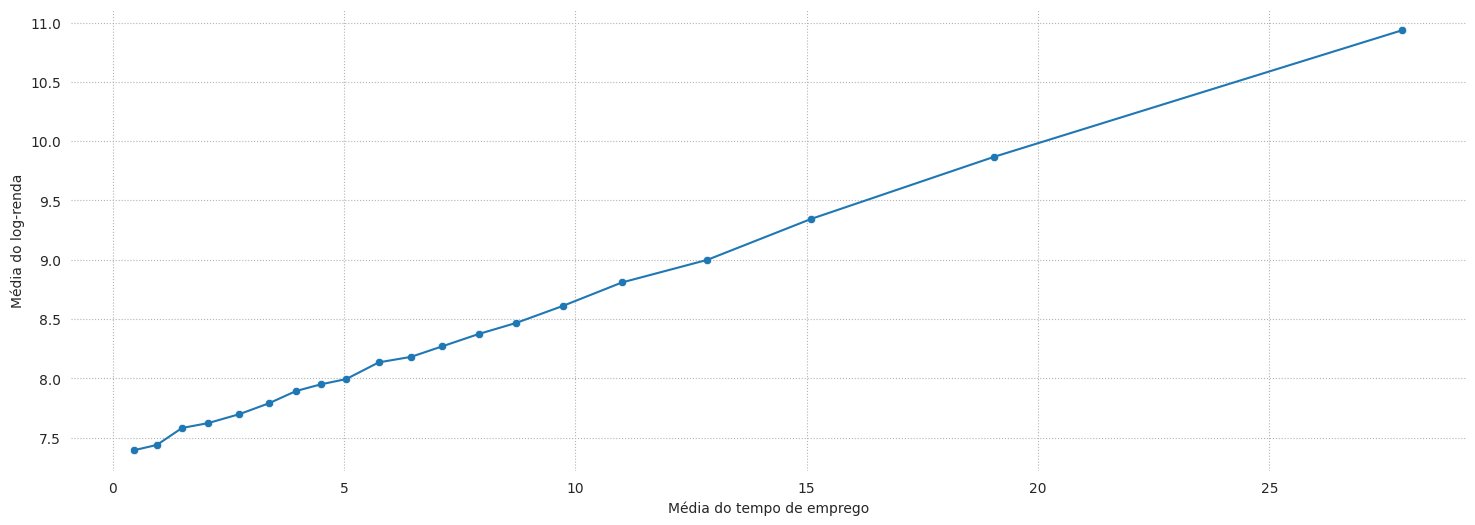

In [12]:
# Configurando o estilo do gráfico com grade branca e estilo de linha pontilhada
sns.set_style("whitegrid", {"grid.color": '.7', "grid.linestyle": ':'})

# Criando uma figura com o tamanho especificado
plt.figure(figsize=(18,6))

# Plotando o gráfico de dispersão
sns.scatterplot(x='Média do tempo de emprego', y='Média do log-renda', data=df_cat)

# Adicionando uma linha de tendência ao gráfico
sns.lineplot(x='Média do tempo de emprego', y='Média do log-renda', data=df_cat)

# Removendo as linhas de grade à esquerda e na parte inferior do gráfico
sns.despine(left=True, bottom=True)

# Exibindo o gráfico
plt.show()

**Comentário**: A análise sugere uma tendência linear constante, surgindo  inicialmente com o uso de uma regressão linear simples. É crucial transformar logarítmica a variável dependente, pois quando utilizada originalmente evidenciaria o crescimento exponencial, como já foi demonstrado pelo espaçamento crescente entre os valores à medida que aumentam.

Considera-se que tanto a categorização quanto a transformação logarítmica ou a regressão segmentada fornece resultados satisfatórios. O método Lowess pode ser a melhor escolha devido à sua capacidade de se ajustar ao formato exponencial, suavizando a curva de acordo com a necessidade.

### Linearização

Experimente pelo menos duas técnicas de linearização vistas ao longo do módulo para melhorar o ajuste da variável ```tempo_emprego```. Compare o $R^2-ajustado$ e avalie se alguma delas apresentou resultados relevantes com relação ao primeiro modelo.


In [13]:
# Criando uma nova coluna 'cat_renda' no DataFrame de treino, contendo os dados da variável 'renda' divididos em categorias com base nos quantis
df_train['cat_renda'], retbins = pd.qcut(x=df_train.renda, q=20, retbins=True, precision=0)

# Imprimindo o número de categorias únicas criadas para 'cat_renda'
print(f'''Quantidade de categorias para 'cat_renda': {df_train.cat_renda.nunique()}''')

# Exibindo o DataFrame de treino atualizado
df_train

Quantidade de categorias para 'cat_renda': 20


,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,tempo_emprego_fillna_mean,qt_pessoas_residencia,renda,renda_log,cat_tempo_emprego,cat_renda
data_ref,,,,,,,,,,,,,,,,,
2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47.0,16.717808,16.717808,2.0,11138.14,9.318131,"(16.6, 21.9]","(8855.0, 11346.0]"
2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30.0,9.600000,9.600000,2.0,2424.81,7.793508,"(9.1, 10.3]","(2248.0, 2547.0]"
2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28.0,8.208219,8.208219,2.0,13749.66,9.528769,"(7.5, 8.3]","(11346.0, 15865.0]"
2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44.0,1.301370,1.301370,4.0,2361.84,7.767196,"(1.2, 1.8]","(2248.0, 2547.0]"
2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33.0,1.254795,1.254795,4.0,790.78,6.673020,"(1.2, 1.8]","(140.0, 841.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-01-01,1503,M,S,S,0,Assalariado,Médio,Casado,Casa,50.0,1.427397,1.427397,2.0,12130.52,9.403480,"(1.2, 1.8]","(11346.0, 15865.0]"
2015-01-01,15507,F,N,N,2,Empresário,Médio,Casado,Casa,37.0,3.624658,3.624658,4.0,503.20,6.220988,"(3.1, 3.6]","(140.0, 841.0]"
2015-01-01,2735,M,N,S,0,Empresário,Médio,Casado,Casa,34.0,11.065753,11.065753,2.0,2364.36,7.768263,"(10.3, 11.9]","(2248.0, 2547.0]"


In [14]:
# Criando um novo DataFrame df_cat2 com estatísticas resumidas para cada categoria da variável 'cat_renda'
df_cat2 = (df_train
           .groupby(by='cat_renda')
           .agg({'cat_renda':[('Quantidade de observações', 'count')],
                 'tempo_emprego': [('Média do tempo de emprego', 'mean')],
                 'renda_log': [('Média do renda_log', 'mean')]})
           .droplevel(level=0, axis=1))

# Exibindo o DataFrame df_cat2
df_cat2

/tmp/ipykernel_1888/1681961040.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(by='cat_renda')


,Quantidade de observações,Média do tempo de emprego,Média do renda_log
cat_renda,,,
"(140.0, 841.0]",2501,2.544220,6.383342
"(841.0, 1165.0]",2500,3.127231,6.909959
"(1165.0, 1445.0]",2502,3.491943,7.175158
"(1445.0, 1717.0]",2498,3.788648,7.364966
"(1717.0, 1983.0]",2499,4.182738,7.520413
"(1983.0, 2248.0]",2501,4.472487,7.656624
"(2248.0, 2547.0]",2499,4.725344,7.781650
"(2547.0, 2874.0]",2504,5.106029,7.902389
"(2874.0, 3256.0]",2496,5.422288,8.027658


In [15]:
# Preenchendo os valores ausentes da coluna 'tempo_emprego' no DataFrame de treino com a média do tempo de emprego correspondente à categoria da variável 'cat_renda'
df_train['tempo_emprego_fillna_2'] = (df_train['tempo_emprego']
                                      .fillna(value=df_train.merge(right=df_cat2,
                                                                   how='left',
                                                                   left_on='cat_renda',
                                                                   right_index=True)['Média do tempo de emprego']))

# Exibindo o DataFrame de treino atualizado
df_train

,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,tempo_emprego_fillna_mean,qt_pessoas_residencia,renda,renda_log,cat_tempo_emprego,cat_renda,tempo_emprego_fillna_2
data_ref,,,,,,,,,,,,,,,,,,
2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47.0,16.717808,16.717808,2.0,11138.14,9.318131,"(16.6, 21.9]","(8855.0, 11346.0]",16.717808
2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30.0,9.600000,9.600000,2.0,2424.81,7.793508,"(9.1, 10.3]","(2248.0, 2547.0]",9.600000
2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28.0,8.208219,8.208219,2.0,13749.66,9.528769,"(7.5, 8.3]","(11346.0, 15865.0]",8.208219
2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44.0,1.301370,1.301370,4.0,2361.84,7.767196,"(1.2, 1.8]","(2248.0, 2547.0]",1.301370
2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33.0,1.254795,1.254795,4.0,790.78,6.673020,"(1.2, 1.8]","(140.0, 841.0]",1.254795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-01-01,1503,M,S,S,0,Assalariado,Médio,Casado,Casa,50.0,1.427397,1.427397,2.0,12130.52,9.403480,"(1.2, 1.8]","(11346.0, 15865.0]",1.427397
2015-01-01,15507,F,N,N,2,Empresário,Médio,Casado,Casa,37.0,3.624658,3.624658,4.0,503.20,6.220988,"(3.1, 3.6]","(140.0, 841.0]",3.624658
2015-01-01,2735,M,N,S,0,Empresário,Médio,Casado,Casa,34.0,11.065753,11.065753,2.0,2364.36,7.768263,"(10.3, 11.9]","(2248.0, 2547.0]",11.065753


In [16]:
# Ajustando um novo modelo de regressão linear utilizando a variável 'tempo_emprego_fillna_2' como preditor da variável 'renda_log' no DataFrame de treino
modelo2 = smf.ols(formula='renda_log ~ tempo_emprego_fillna_2', data=df_train).fit()

# Imprimindo o R-quadrado ajustado dos dois modelos
print(f'R-quadrado ajustado (modelo1): {modelo1.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo2): {modelo2.rsquared_adj:.2%}')

# Exibindo um resumo do segundo modelo
modelo2.summary()

R-quadrado ajustado (modelo1): 53.41%
R-quadrado ajustado (modelo2): 59.17%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              renda_log   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                 7.245e+04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:56:48   Log-Likelihood:                -52705.
No. Observations:               50000   AIC:                         1.054e+05
Df Residuals:                   49998   BIC:                         1.054e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7.3137      0.005   1511.209      0.000       7.304       7.323
tempo_emprego_fillna_2     0.1334      0.000    269.157      0.000       0.132       0.134
==============================================================================
Omnibus:                      140.982   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              184.130
Skew:                          -0.007   Prob(JB):                     1.04e-40
Kurtosis:                       3.297   Cond. No.                         15.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# Ajustando um terceiro modelo de regressão linear utilizando os dados resumidos do DataFrame df_cat2
modelo3 = smf.ols(formula='Q("Média do renda_log") ~ Q("Média do tempo de emprego")', data=df_cat2).fit()

# Imprimindo o R-quadrado ajustado dos três modelos
print(f'R-quadrado ajustado (modelo1): {modelo1.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo2): {modelo2.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo3): {modelo3.rsquared_adj:.2%}')

# Exibindo um resumo do terceiro modelo
modelo3.summary()

R-quadrado ajustado (modelo1): 53.41%
R-quadrado ajustado (modelo2): 59.17%
R-quadrado ajustado (modelo3): 88.72%


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("Média do renda_log")   R-squared:                       0.893
Model:                                 OLS   Adj. R-squared:                  0.887
Method:                      Least Squares   F-statistic:                     150.5
Date:                     Thu, 12 Mar 2026   Prob (F-statistic):           3.53e-10
Time:                             00:56:50   Log-Likelihood:                -7.3979
No. Observations:                       20   AIC:                             18.80
Df Residuals:                           18   BIC:                             20.79
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          6.7942      0.149     45.659      0.000       6.482       7.107
Q("Média do tempo de emprego")     0.2028      0.017     12.268      0.000       0.168       0.237
==============================================================================
Omnibus:                        6.961   Durbin-Watson:                   0.303
Prob(Omnibus):                  0.031   Jarque-Bera (JB):                4.871
Skew:                          -1.182   Prob(JB):                       0.0876
Kurtosis:                       3.509   Cond. No.                         16.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
# Combinando os resultados do modelo de regressão linear (modelo3) com as estatísticas resumidas do DataFrame df_cat2
df_modelo3 = (df_cat2
              .merge(right=modelo3.get_prediction().summary_frame(),
                     on='cat_renda')
              .rename(columns={'Quantidade de observações':'qtd',
                               'Média do tempo de emprego':'tempo_emprego',
                               'Média do renda_log':'renda_log'}))

# Exibindo o DataFrame df_modelo3
df_modelo3

,qtd,tempo_emprego,renda_log,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
cat_renda,,,,,,,,,
"(140.0, 841.0]",2501,2.544220,6.383342,7.310021,0.116186,7.065923,7.554118,6.496819,8.123223
"(841.0, 1165.0]",2500,3.127231,6.909959,7.428231,0.109620,7.197927,7.658534,6.619062,8.237399
"(1165.0, 1445.0]",2502,3.491943,7.175158,7.502179,0.105752,7.280002,7.724356,6.695286,8.309072
"(1445.0, 1717.0]",2498,3.788648,7.364966,7.562338,0.102759,7.346449,7.778227,6.757154,8.367523
"(1717.0, 1983.0]",2499,4.182738,7.520413,7.642243,0.099019,7.434211,7.850275,6.839129,8.445356
"(1983.0, 2248.0]",2501,4.472487,7.656624,7.700992,0.096458,7.498341,7.903643,6.899255,8.502728
"(2248.0, 2547.0]",2499,4.725344,7.781650,7.752261,0.094365,7.554007,7.950514,6.951624,8.552897
"(2547.0, 2874.0]",2504,5.106029,7.902389,7.829448,0.091484,7.637248,8.021647,7.030289,8.628606
"(2874.0, 3256.0]",2496,5.422288,8.027658,7.893572,0.089356,7.705841,8.081302,7.095476,8.691667


In [19]:
# Criando uma função para plotar os resultados de um modelo de regressão
def plotar_resultados_regressao(data: pd.DataFrame) -> None:
    """
    Plota os dados observados, a média prevista e os intervalos de confiança de um modelo de regressão.

    Parâmetros:
        data (pd.DataFrame): DataFrame contendo os resultados da regressão.

    Retorna:
        None
    """
    # Criação do gráfico para exibir os resultados do modelo de regressão linear
    plt.figure(figsize=(18, 6))

    # Configurando o estilo do gráfico
    sns.set_theme(style='white')

    # Plotando os dados observados
    plt.plot(data['tempo_emprego'], data['renda_log'], 'bo', alpha=.9, label='Dados observados')

    # Plotando uma linha conectando os dados observados
    plt.plot(data['tempo_emprego'], data['renda_log'], '-', alpha=.3)

    # Plotando a média prevista
    plt.plot(data['tempo_emprego'], data['mean'], 'g-.', label='Média prevista')

    # Plotando o intervalo de confiança da média
    plt.plot(data['tempo_emprego'], data['mean_ci_lower'], ':', color='orange', label='Intervalo de confiança da média')
    plt.plot(data['tempo_emprego'], data['mean_ci_upper'], ':', color='orange')

    # Plotando o intervalo de confiança para a variável de resposta
    plt.plot(data['tempo_emprego'], data['obs_ci_lower'], 'r--', label='Intervalo de confiança para a variável de resposta')
    plt.plot(data['tempo_emprego'], data['obs_ci_upper'], 'r--')

    # Adicionando legenda
    plt.legend(loc='best')

    # Exibindo o gráfico
    plt.show()

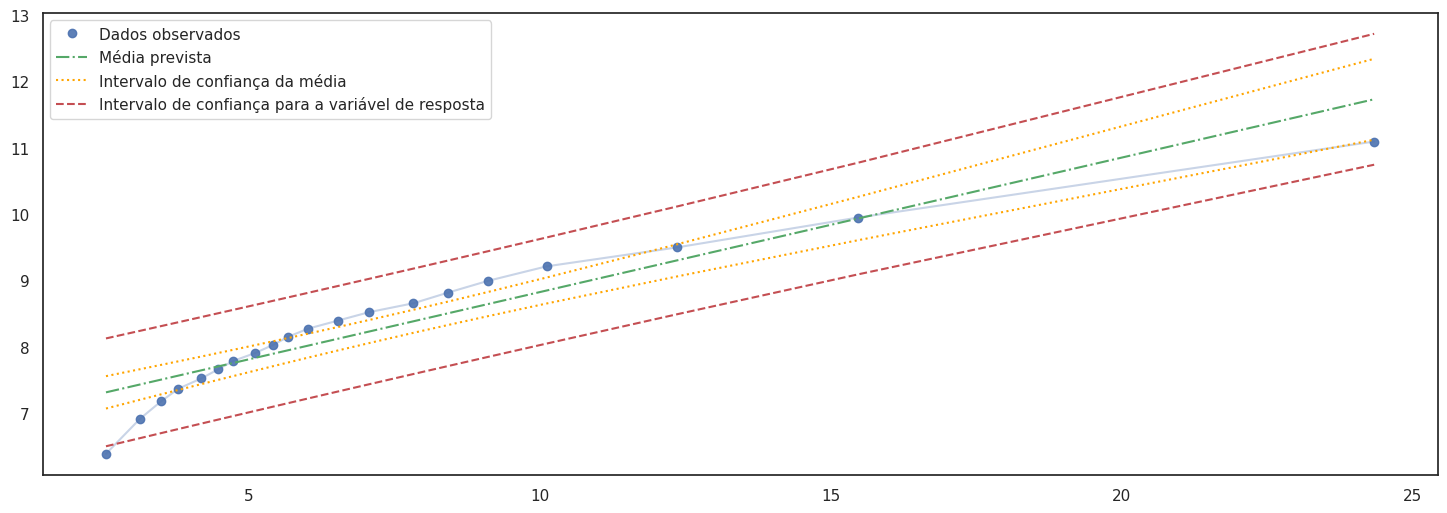

In [20]:
# Chamando a função para exibir o gráfico com os resultados do modelo de regressão linear (modelo3)
plotar_resultados_regressao(data=df_modelo3)

In [21]:
# Criando um novo DataFrame df_train2 a partir do DataFrame df_cat2
# Selecionando apenas as colunas relevantes (tempo_emprego e renda_log), redefinindo os índices e renomeando as colunas
df_train2 = (df_cat2
             .iloc[:,1:]  # Excluindo a primeira coluna
             .reset_index(drop=True)  # Redefinindo os índices
             .rename(columns={'Média do tempo de emprego':'tempo_emprego', 'Média do renda_log':'renda_log'}))  # Renomeando as colunas

# Exibindo o DataFrame df_train2
df_train2

,tempo_emprego,renda_log
0,2.544220,6.383342
1,3.127231,6.909959
2,3.491943,7.175158
3,3.788648,7.364966
4,4.182738,7.520413
5,4.472487,7.656624
6,4.725344,7.781650
7,5.106029,7.902389
8,5.422288,8.027658
9,5.681121,8.150253


In [22]:
# Dividindo a variável 'tempo_emprego' em 10 categorias usando quantis e retornando os pontos de corte dos intervalos de cada categoria
df_train2['tempo_emprego_cat'], q = pd.qcut(x=df_train2.tempo_emprego, q=10, retbins=True, duplicates='drop')

# Exibindo os pontos de corte dos intervalos de cada categoria
q

array([ 2.54421988,  3.45547201,  4.10391957,  4.64948646,  5.29578453,
        5.8520934 ,  6.74732634,  8.0077913 ,  9.31576895, 12.66190399,
       24.34153605])

In [23]:
# Definindo os pontos de corte para dividir a variável 'tempo_emprego' em intervalos
q = [-np.inf, #2.82831955,
     3.88489973,
     4.52253642,
#      5.01507938,
     5.54815254,
#      6.1206601,
     6.82530007,
#      7.86743048,
     9.2254007,
#      11.88062575,
     np.inf #22.86804915
    ]

# Criando uma nova coluna 'tempo_emprego_cat' no DataFrame df_train2, contendo os intervalos definidos pelos pontos de corte
df_train2['tempo_emprego_cat'] = pd.cut(x=df_train2.tempo_emprego, bins=q)

# Criando um novo DataFrame df_train3
df_train3 = pd.DataFrame()

# Calculando a média da variável 'renda_log' para cada intervalo da variável 'tempo_emprego_cat'
df_train3['y_mean'] = df_train2.groupby(by='tempo_emprego_cat')['renda_log'].mean()

# Calculando o erro padrão da média da variável 'renda_log' para cada intervalo da variável 'tempo_emprego_cat'
std_error = df_train2.groupby(by='tempo_emprego_cat')['renda_log'].sem()

# Calculando os limites superior e inferior do intervalo de confiança de 95% para a média da variável 'renda_log'
df_train3['y_max'] = df_train3['y_mean'] + std_error * 2
df_train3['y_min'] = df_train3['y_mean'] - std_error * 2

# Combinando os resultados com o DataFrame df_train2
df_train3 = df_train2.merge(right=df_train3, how='left', left_on='tempo_emprego_cat', right_index=True)

# Exibindo o DataFrame df_train3
df_train3

/tmp/ipykernel_1888/169951935.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train3['y_mean'] = df_train2.groupby(by='tempo_emprego_cat')['renda_log'].mean()
/tmp/ipykernel_1888/169951935.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_error = df_train2.groupby(by='tempo_emprego_cat')['renda_log'].sem()


,tempo_emprego,renda_log,tempo_emprego_cat,y_mean,y_max,y_min
0,2.544220,6.383342,"(-inf, 3.885]",6.958356,7.384704,6.532008
1,3.127231,6.909959,"(-inf, 3.885]",6.958356,7.384704,6.532008
2,3.491943,7.175158,"(-inf, 3.885]",6.958356,7.384704,6.532008
3,3.788648,7.364966,"(-inf, 3.885]",6.958356,7.384704,6.532008
4,4.182738,7.520413,"(3.885, 4.523]",7.588518,7.724730,7.452307
5,4.472487,7.656624,"(3.885, 4.523]",7.588518,7.724730,7.452307
6,4.725344,7.781650,"(4.523, 5.548]",7.903899,8.045940,7.761858
7,5.106029,7.902389,"(4.523, 5.548]",7.903899,8.045940,7.761858
8,5.422288,8.027658,"(4.523, 5.548]",7.903899,8.045940,7.761858
9,5.681121,8.150253,"(5.548, 6.825]",8.271441,8.411339,8.131543


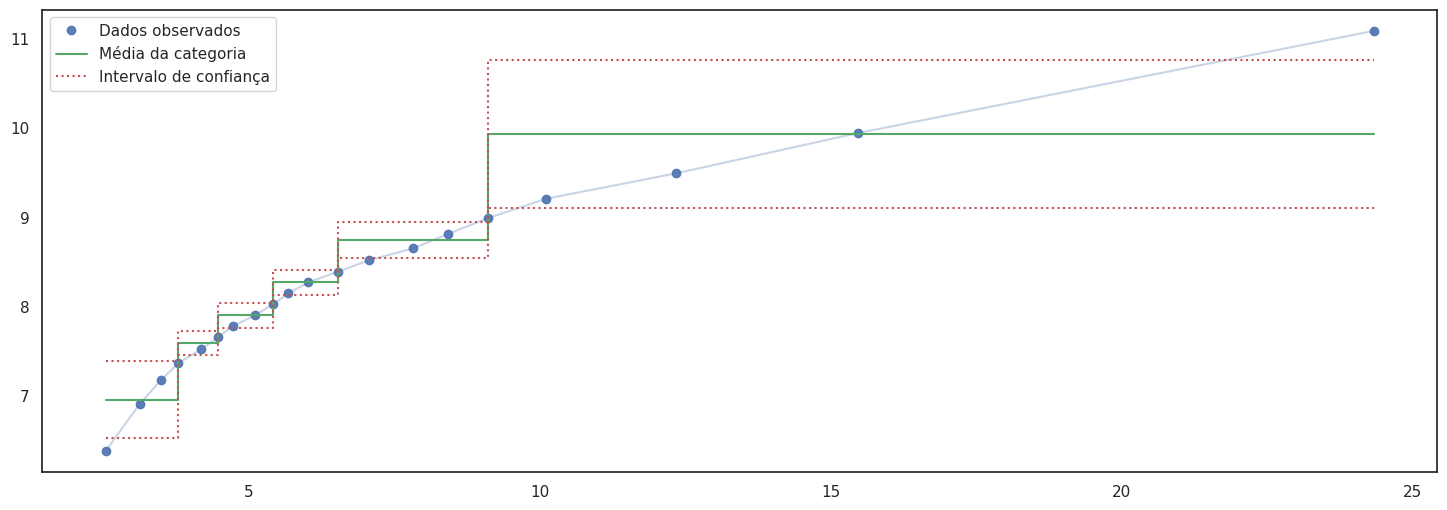

In [24]:
# Criando um gráfico para visualizar os dados observados, a média da categoria e o intervalo de confiança da variável 'renda_log' em relação à variável 'tempo_emprego'
plt.figure(figsize=(18,6))

# Plotando os dados observados
plt.plot(df_train3.tempo_emprego, df_train3.renda_log, 'bo', alpha=.9, label='Dados observados')

# Plotando uma linha conectando os dados observados
plt.plot(df_train3.tempo_emprego, df_train3.renda_log, '-', alpha=.3)

# Plotando a média da categoria
plt.step(df_train3.tempo_emprego, df_train3.y_mean, 'g-', label='Média da categoria')

# Plotando o intervalo de confiança
plt.step(df_train3.tempo_emprego, df_train3.y_max, 'r:', label='Intervalo de confiança')
plt.step(df_train3.tempo_emprego, df_train3.y_min, 'r:')

# Adicionando legenda
plt.legend(loc='best')

# Exibindo o gráfico
plt.show()

In [25]:
# Ajustando um novo modelo de regressão linear usando a variável categórica 'tempo_emprego_cat' como preditora da variável 'renda_log' no DataFrame df_train3
modelo4 = smf.ols(formula='renda_log ~ tempo_emprego_cat', data=df_train3).fit()

# Imprimindo o R-quadrado ajustado dos quatro modelos anteriores
print(f'R-quadrado ajustado (modelo1): {modelo1.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo2): {modelo2.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo3): {modelo3.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo4): {modelo4.rsquared_adj:.2%}')

# Exibindo um resumo completo do quarto modelo
modelo4.summary()

R-quadrado ajustado (modelo1): 53.41%
R-quadrado ajustado (modelo2): 59.17%
R-quadrado ajustado (modelo3): 88.72%
R-quadrado ajustado (modelo4): 83.47%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              renda_log   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     20.19
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.98e-06
Time:                        00:58:24   Log-Likelihood:                -8.7105
No. Observations:                  20   AIC:                             29.42
Df Residuals:                      14   BIC:                             35.40
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================================================================
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       6.9584      0.224     31.130      0.000       6.479       7.438
tempo_emprego_cat[T.Interval(3.885, 4.523, closed='right')]     0.6302      0.387      1.628      0.126      -0.200       1.461
tempo_emprego_cat[T.Interval(4.523, 5.548, closed='right')]     0.9455      0.341      2.769      0.015       0.213       1.678
tempo_emprego_cat[T.Interval(5.548, 6.825, closed='right')]     1.3131      0.341      3.846      0.002       0.581       2.045
tempo_emprego_cat[T.Interval(6.825, 9.225, closed='right')]     1.7867      0.316      5.652      0.000       1.109       2.465
tempo_emprego_cat[T.Interval(9.225, inf, closed='right')]       2.9770      0.316      9.418      0.000       2.299       3.655
==============================================================================
Omnibus:                       10.123   Durbin-Watson:                   1.260
Prob(Omnibus):                  0.006   Jarque-Bera (JB):                9.170
Skew:                           0.927   Prob(JB):                       0.0102
Kurtosis:                       5.750   Cond. No.                         6.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

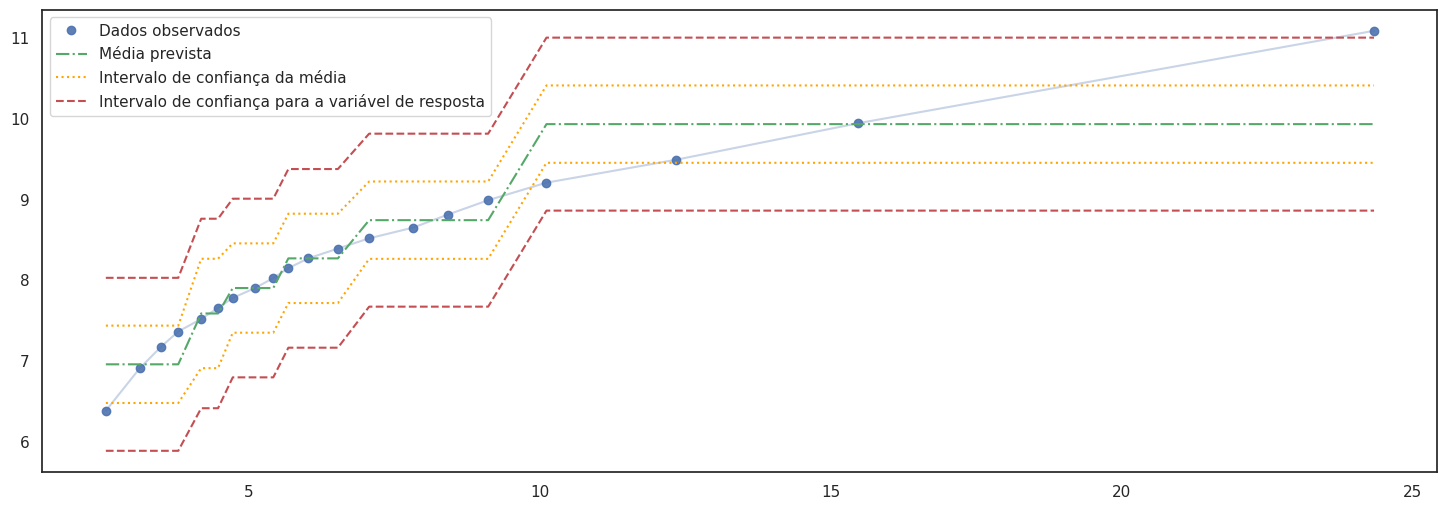

In [26]:
# Concatenando os resultados do modelo de regressão linear (modelo4) com os dados do DataFrame df_train3
df_modelo4 = pd.concat(objs=[df_train3, modelo4.get_prediction().summary_frame()], axis=1)

# Chamando a função para exibir o gráfico com os resultados do modelo de regressão linear (modelo4)
plotar_resultados_regressao(data=df_modelo4)

In [27]:
# Ajustando um novo modelo de regressão linear usando o logaritmo natural da variável 'tempo_emprego' como preditora da variável 'renda_log' no DataFrame df_train2
modelo5 = smf.ols(formula='renda_log ~ I(np.log(tempo_emprego))', data=df_train2).fit()

# Imprimindo o R-quadrado ajustado dos cinco modelos anteriores
print(f'R-quadrado ajustado (modelo1): {modelo1.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo2): {modelo2.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo3): {modelo3.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo4): {modelo4.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo5): {modelo5.rsquared_adj:.2%}')

# Exibindo um resumo completo do quinto modelo
modelo5.summary()

R-quadrado ajustado (modelo1): 53.41%
R-quadrado ajustado (modelo2): 59.17%
R-quadrado ajustado (modelo3): 88.72%
R-quadrado ajustado (modelo4): 83.47%
R-quadrado ajustado (modelo5): 99.57%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              renda_log   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     4380.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           5.98e-23
Time:                        00:58:29   Log-Likelihood:                 25.223
No. Observations:                  20   AIC:                            -46.45
Df Residuals:                      18   BIC:                            -44.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.6898      0.057     82.167      0.000       4.570       4.810
I(np.log(tempo_emprego))     1.9594      0.030     66.185      0.000       1.897       2.022
==============================================================================
Omnibus:                        0.628   Durbin-Watson:                   1.145
Prob(Omnibus):                  0.731   Jarque-Bera (JB):                0.315
Skew:                          -0.299   Prob(JB):                        0.854
Kurtosis:                       2.857   Cond. No.                         8.52
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
# Combinando os resultados do modelo de regressão linear (modelo5) com as duas primeiras colunas do DataFrame df_train2
df_modelo5 = pd.concat(objs=[df_train2.iloc[:,:2], modelo5.get_prediction().summary_frame().reset_index(drop=True)], axis=1)

# Exibindo o DataFrame df_modelo5
df_modelo5

,tempo_emprego,renda_log,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2.544220,6.383342,6.519538,0.031549,6.453256,6.585820,6.353874,6.685201
1,3.127231,6.909959,6.923802,0.026488,6.868152,6.979451,6.762098,7.085505
2,3.491943,7.175158,7.139940,0.023984,7.089552,7.190327,6.979971,7.299908
3,3.788648,7.364966,7.299727,0.022259,7.252963,7.346492,7.140862,7.458592
4,4.182738,7.520413,7.493620,0.020356,7.450854,7.536386,7.335886,7.651354
5,4.472487,7.656624,7.624855,0.019215,7.584487,7.665223,7.467754,7.781956
6,4.725344,7.781650,7.732612,0.018385,7.693987,7.771237,7.575950,7.889274
7,5.106029,7.902389,7.884427,0.017408,7.847854,7.920999,7.728258,8.040595
8,5.422288,8.027658,8.002176,0.016827,7.966823,8.037530,7.846289,8.158064
9,5.681121,8.150253,8.093543,0.016496,8.058887,8.128199,7.937812,8.249274


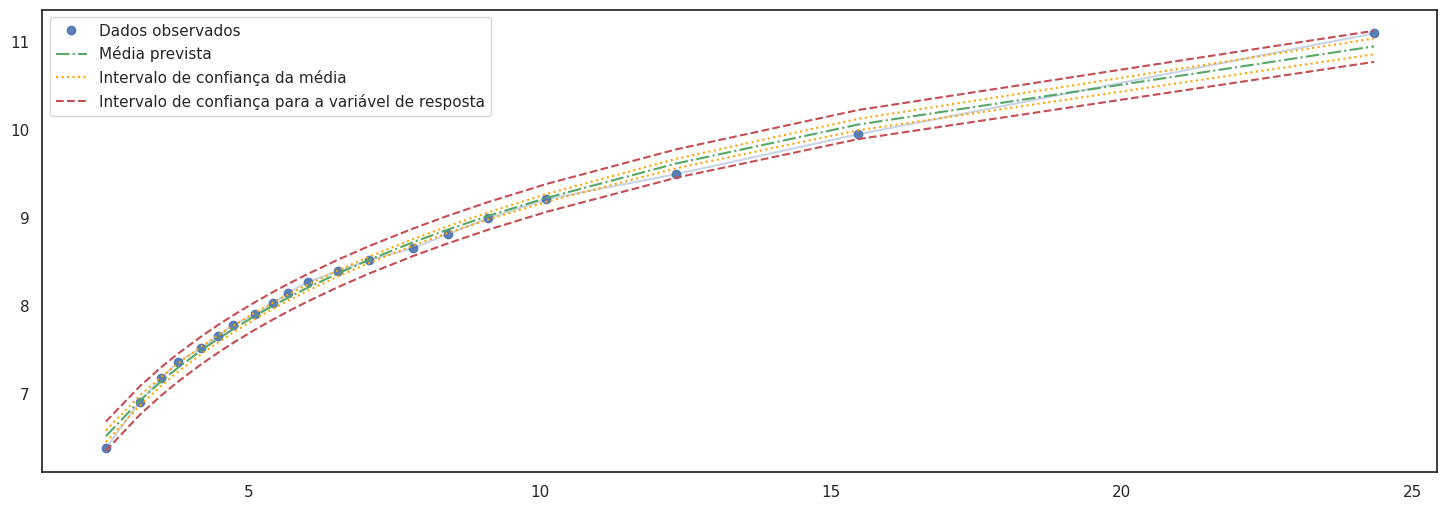

In [29]:
# Chamando a função para exibir o gráfico com os resultados do modelo de regressão linear (modelo5)
plotar_resultados_regressao(data=df_modelo5)

In [30]:
# Regressão segmentada

# Definindo um ponto de corte
C1 = 7.5

# Criando duas novas colunas no DataFrame df_train2, X_1 e X_2
# Preenchendo as colunas com valores da variável 'tempo_emprego' de acordo com a seguinte lógica:
# Se o valor da variável 'tempo_emprego' for menor ou igual a C1, o valor é mantido; caso contrário, o valor é substituído por C1
df_train2['X_1'] = (df_train2['tempo_emprego'] <= C1) * df_train2['tempo_emprego'] + (df_train2['tempo_emprego'] > C1) * C1
# X_2 contém os valores originais de 'tempo_emprego' se forem maiores que C1, caso contrário, os valores são substituídos por C1
df_train2['X_2'] = (df_train2['tempo_emprego'] > C1) * df_train2['tempo_emprego'] + (df_train2['tempo_emprego'] <= C1) * C1

# Exibindo o DataFrame df_train2
df_train2

,tempo_emprego,renda_log,tempo_emprego_cat,X_1,X_2
0,2.544220,6.383342,"(-inf, 3.885]",2.544220,7.500000
1,3.127231,6.909959,"(-inf, 3.885]",3.127231,7.500000
2,3.491943,7.175158,"(-inf, 3.885]",3.491943,7.500000
3,3.788648,7.364966,"(-inf, 3.885]",3.788648,7.500000
4,4.182738,7.520413,"(3.885, 4.523]",4.182738,7.500000
5,4.472487,7.656624,"(3.885, 4.523]",4.472487,7.500000
6,4.725344,7.781650,"(4.523, 5.548]",4.725344,7.500000
7,5.106029,7.902389,"(4.523, 5.548]",5.106029,7.500000
8,5.422288,8.027658,"(4.523, 5.548]",5.422288,7.500000
9,5.681121,8.150253,"(5.548, 6.825]",5.681121,7.500000


In [31]:
# Ajustando um novo modelo de regressão linear (modelo6) usando as variáveis 'X_1' e 'X_2' como preditoras da variável 'renda_log' no DataFrame df_train2
modelo6 = smf.ols(formula='renda_log ~ X_1 + X_2', data=df_train2).fit()

# Imprimindo o R-quadrado ajustado dos seis modelos anteriores
print(f'R-quadrado ajustado (modelo1): {modelo1.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo2): {modelo2.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo3): {modelo3.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo4): {modelo4.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo5): {modelo5.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo6): {modelo6.rsquared_adj:.2%}')

# Exibindo um resumo completo do sexto modelo
modelo6.summary()

R-quadrado ajustado (modelo1): 53.41%
R-quadrado ajustado (modelo2): 59.17%
R-quadrado ajustado (modelo3): 88.72%
R-quadrado ajustado (modelo4): 83.47%
R-quadrado ajustado (modelo5): 99.57%
R-quadrado ajustado (modelo6): 98.59%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              renda_log   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     665.3
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           7.20e-17
Time:                        00:58:37   Log-Likelihood:                 13.965
No. Observations:                  20   AIC:                            -21.93
Df Residuals:                      17   BIC:                            -18.94
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6610      0.107     43.498      0.000       4.435       4.887
X_1            0.4157      0.020     21.014      0.000       0.374       0.457
X_2            0.1370      0.008     16.594      0.000       0.120       0.154
==============================================================================
Omnibus:                       12.134   Durbin-Watson:                   0.525
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                9.750
Skew:                          -1.455   Prob(JB):                      0.00764
Kurtosis:                       4.798   Cond. No.                         43.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
# Combinando os resultados do modelo de regressão linear (modelo6) com as colunas do DataFrame df_train2
df_modelo6 = pd.concat(objs=[df_train2.iloc[:,[0,1,3,4]], modelo6.get_prediction().summary_frame()], axis=1)

# Exibindo o DataFrame df_modelo6
df_modelo6

,tempo_emprego,renda_log,X_1,X_2,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2.544220,6.383342,2.544220,7.500000,6.746381,0.064732,6.609808,6.882954,6.438928,7.053834
1,3.127231,6.909959,3.127231,7.500000,6.988745,0.054990,6.872726,7.104763,6.689854,7.287635
2,3.491943,7.175158,3.491943,7.500000,7.140359,0.049290,7.036366,7.244353,6.845928,7.434791
3,3.788648,7.364966,3.788648,7.500000,7.263703,0.044975,7.168813,7.358593,6.972362,7.555043
4,4.182738,7.520413,4.182738,7.500000,7.427530,0.039864,7.343425,7.511635,7.139522,7.715538
5,4.472487,7.656624,4.472487,7.500000,7.547982,0.036712,7.470526,7.625438,7.261844,7.834119
6,4.725344,7.781650,4.725344,7.500000,7.653097,0.034509,7.580289,7.725905,7.368183,7.938012
7,5.106029,7.902389,5.106029,7.500000,7.811352,0.032389,7.743017,7.879687,7.527548,8.095157
8,5.422288,8.027658,5.422288,7.500000,7.942825,0.031898,7.875526,8.010123,7.659268,8.226381
9,5.681121,8.150253,5.681121,7.500000,8.050424,0.032402,7.982061,8.118787,7.766613,8.334235


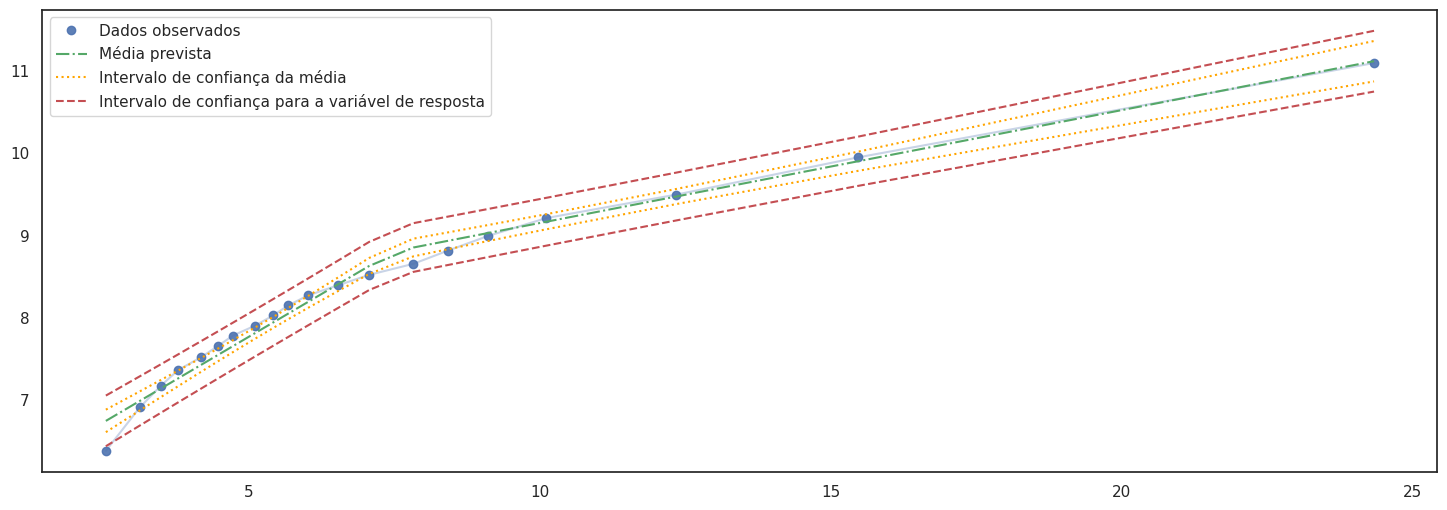

In [33]:
# Chamando a função para exibir o gráfico com os resultados do modelo de regressão linear (modelo6)
plotar_resultados_regressao(data=df_modelo6)

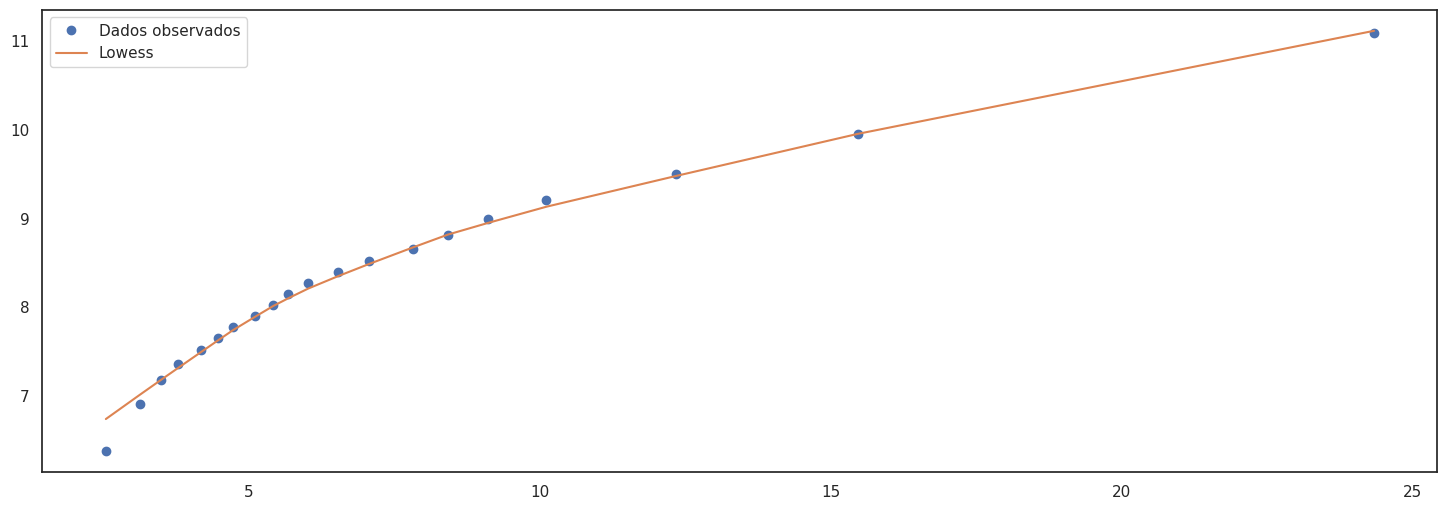

In [34]:
# Lowless

# Aplicando o método LOWESS (Local Regression) para ajustar uma linha suave aos dados de 'renda_log' em relação a 'tempo_emprego' no DataFrame df_train2
lowess = sm.nonparametric.lowess(endog=df_train2['renda_log'], exog=df_train2['tempo_emprego'], frac=2/3)

# Criando um gráfico para visualizar os dados observados e a linha suavizada LOWESS
plt.figure(figsize=(18,6))

# Plotando os dados observados
plt.plot(df_train2['tempo_emprego'], df_train2['renda_log'], 'o', label='Dados observados')

# Plotando a linha suavizada LOWESS
plt.plot(df_train2['tempo_emprego'], lowess[:,1], label='Lowess')

# Adicionando legenda
plt.legend()

# Exibindo o gráfico
plt.show()

In [35]:
# Usando a função interp1d para interpolar os valores suavizados gerados pelo método LOWESS
f = interp1d(x=lowess[:,0], y=lowess[:,1], bounds_error=False)

# Adicionando os valores interpolados como uma nova coluna chamada 'lowess' no DataFrame df_train2
df_train2['lowess'] = f(df_train2['tempo_emprego'])

# Exibindo o DataFrame df_train2 com a nova coluna 'lowess'
df_train2

,tempo_emprego,renda_log,tempo_emprego_cat,X_1,X_2,lowess
0,2.544220,6.383342,"(-inf, 3.885]",2.544220,7.500000,6.740990
1,3.127231,6.909959,"(-inf, 3.885]",3.127231,7.500000,7.013692
2,3.491943,7.175158,"(-inf, 3.885]",3.491943,7.500000,7.181812
3,3.788648,7.364966,"(-inf, 3.885]",3.788648,7.500000,7.317350
4,4.182738,7.520413,"(3.885, 4.523]",4.182738,7.500000,7.496191
5,4.472487,7.656624,"(3.885, 4.523]",4.472487,7.500000,7.626919
6,4.725344,7.781650,"(4.523, 5.548]",4.725344,7.500000,7.740110
7,5.106029,7.902389,"(4.523, 5.548]",5.106029,7.500000,7.891183
8,5.422288,8.027658,"(4.523, 5.548]",5.422288,7.500000,8.014190
9,5.681121,8.150253,"(5.548, 6.825]",5.681121,7.500000,8.101184


In [36]:
# Ajustando um novo modelo de regressão linear (modelo7) usando a variável 'lowess' como preditora da variável 'renda_log' no DataFrame df_train2
modelo7 = smf.ols(formula='renda_log ~ lowess', data=df_train2).fit()

# Imprimindo o R-quadrado ajustado dos sete modelos anteriores
print(f'R-quadrado ajustado (modelo1): {modelo1.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo2): {modelo2.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo3): {modelo3.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo4): {modelo4.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo5): {modelo5.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo6): {modelo6.rsquared_adj:.2%}')
print(f'R-quadrado ajustado (modelo7): {modelo7.rsquared_adj:.2%}')

# Exibindo um resumo completo do sétimo modelo
modelo7.summary()

R-quadrado ajustado (modelo1): 53.41%
R-quadrado ajustado (modelo2): 59.17%
R-quadrado ajustado (modelo3): 88.72%
R-quadrado ajustado (modelo4): 83.47%
R-quadrado ajustado (modelo5): 99.57%
R-quadrado ajustado (modelo6): 98.59%
R-quadrado ajustado (modelo7): 99.33%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              renda_log   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2824.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.05e-21
Time:                        01:00:41   Log-Likelihood:                 20.857
No. Observations:                  20   AIC:                            -37.71
Df Residuals:                      18   BIC:                            -35.72
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2365      0.162     -1.459      0.162      -0.577       0.104
lowess         1.0283      0.019     53.144      0.000       0.988       1.069
==============================================================================
Omnibus:                       28.605   Durbin-Watson:                   0.623
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               50.936
Skew:                          -2.416   Prob(JB):                     8.70e-12
Kurtosis:                       9.146   Cond. No.                         68.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [92]:
# Combinando os resultados do modelo de regressão linear (modelo7) com as colunas do DataFrame df_train2
df_modelo7 = pd.concat(objs=[df_train2.iloc[:,[0,1,5]], modelo7.get_prediction().summary_frame()], axis=1)

# Exibindo o DataFrame df_modelo7
df_modelo7

,tempo_emprego,renda_log,lowess,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,2.544220,6.383342,6.740990,6.695171,0.036479,6.618532,6.771810,6.491347,6.898996
1,3.127231,6.909959,7.013692,6.975586,0.032207,6.907921,7.043250,6.774963,7.176208
2,3.491943,7.175158,7.181812,7.148460,0.029735,7.085989,7.210931,6.949530,7.347391
3,3.788648,7.364966,7.317350,7.287832,0.027859,7.229302,7.346362,7.090103,7.485561
4,4.182738,7.520413,7.496191,7.471732,0.025585,7.417979,7.525485,7.275364,7.668099
5,4.472487,7.656624,7.626919,7.606157,0.024103,7.555519,7.656794,7.410619,7.801695
6,4.725344,7.781650,7.740110,7.722550,0.022967,7.674298,7.770801,7.527616,7.917483
7,5.106029,7.902389,7.891183,7.877895,0.021704,7.832296,7.923494,7.683601,8.072189
8,5.422288,8.027658,8.014190,8.004381,0.020923,7.960423,8.048339,7.810466,8.198297
9,5.681121,8.150253,8.101184,8.093835,0.020520,8.050725,8.136946,7.900110,8.287561


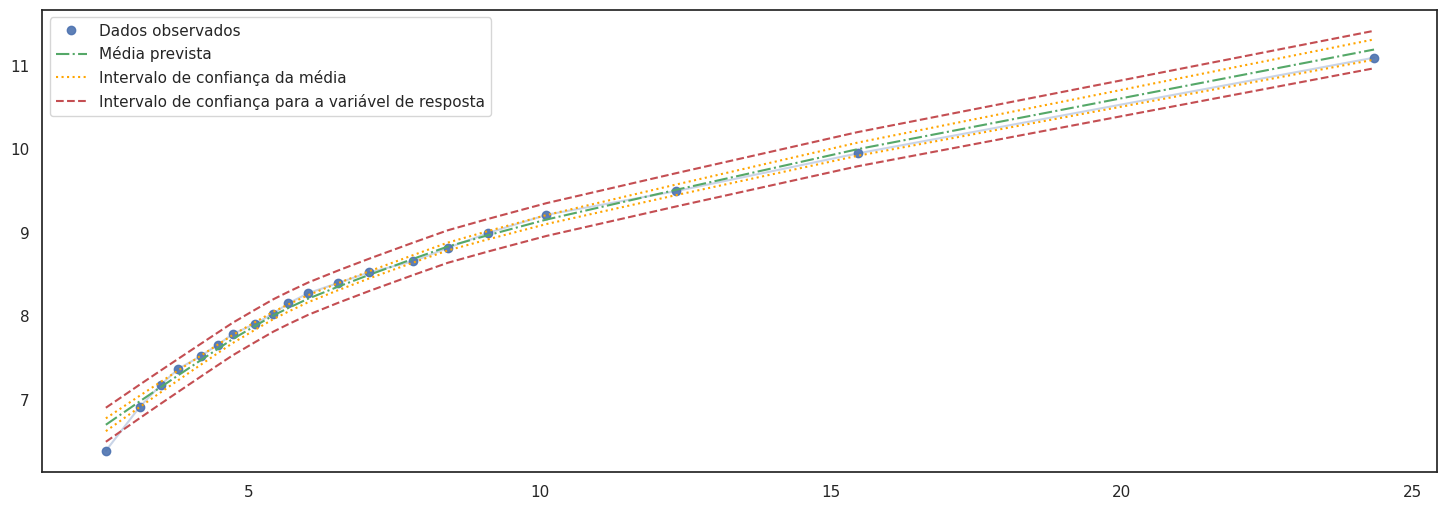

In [93]:
# Chamando a função para exibir o gráfico com os resultados do modelo de regressão linear (modelo7)
plotar_resultados_regressao(data=df_modelo7)

### Avaliando o modelo

Avalie os resultados dos modelos construidos na base de testes.

In [94]:
# Criando o DataFrame df_, que agrupa os dados por intervalos de renda e calcula a média do tempo de emprego preenchido e do logaritmo da renda
df_ = (df_train
       .groupby(by=['data_ref', pd.cut(df_train.renda, bins=retbins)])
       .agg({'tempo_emprego_fillna_2':'mean', 'renda_log':'mean'})
       .reset_index()
       .rename(columns={'tempo_emprego_fillna_2':'tempo_emprego'})
)

# Exibindo o DataFrame df_
df_

/tmp/ipykernel_1888/753332063.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(by=['data_ref', pd.cut(df_train.renda, bins=retbins)])


,data_ref,renda,tempo_emprego,renda_log
0,2015-01-01,"(141.25, 840.7]",2.545496,6.386788
1,2015-01-01,"(840.7, 1165.18]",3.127231,6.909959
2,2015-01-01,"(1165.18, 1445.33]",3.491943,7.175158
3,2015-01-01,"(1445.33, 1716.57]",3.788648,7.364966
4,2015-01-01,"(1716.57, 1982.888]",4.182738,7.520413
5,2015-01-01,"(1982.888, 2247.62]",4.472487,7.656624
6,2015-01-01,"(2247.62, 2547.468]",4.725344,7.781650
7,2015-01-01,"(2547.468, 2873.68]",5.106029,7.902389
8,2015-01-01,"(2873.68, 3255.539]",5.422288,8.027658
9,2015-01-01,"(3255.539, 3675.545]",5.681121,8.150253


In [98]:
# Dividindo o DataFrame df_ em conjuntos de treinamento e teste com base em datas
df_ = (df_train
       .groupby(by=['data_ref', pd.cut(df_train.renda, bins=retbins)])
       .agg({'tempo_emprego_fillna_2':'mean', 'renda_log':'mean'})
       .reset_index()
       .rename(columns={'tempo_emprego_fillna_2':'tempo_emprego'})
       .set_index('data_ref')   # garante que o índice seja datetime
)
df_test_ = df_[~df_.index.isin(df_train_.index)].copy()  # Conjunto de teste contendo os dados restantes

# Imprimindo informações sobre o tamanho e as datas dos conjuntos de treinamento e teste
print(f'''
Base de treino: {df_train_.shape} - {df_train_.index.unique().strftime('%b%y').values}
Base de teste: {df_test_.shape} - {df_test_.index.unique().strftime('%b%y').values}
''')


Base de treino: (0, 5) - []
Base de teste: (20, 3) - ['Jan15']



/tmp/ipykernel_1888/3422608515.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(by=['data_ref', pd.cut(df_train.renda, bins=retbins)])
